# Data Mining Assignment 2 – Preprocessing
Load, clean, encode, normalise, merge and save the datasets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Raw Data

In [2]:
movies  = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings_train.csv')

print('movies shape :', movies.shape)
print('ratings shape:', ratings.shape)
movies.head(3)

movies shape : (9742, 3)
ratings shape: (97801, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


In [3]:
ratings.head(3)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


## 2. Missing Value Analysis

In [4]:
print('=== movies missing values ===')
print(movies.isnull().sum())
print()
print('=== ratings missing values ===')
print(ratings.isnull().sum())

=== movies missing values ===
movieId    0
title      0
genres     0
dtype: int64

=== ratings missing values ===
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [5]:
# Handle '(no genres listed)' as missing genre
no_genre_mask = movies['genres'] == '(no genres listed)'
print(f"Movies with no genre listed: {no_genre_mask.sum()}")

# Replace with NaN, then fill with 'Unknown'
movies.loc[no_genre_mask, 'genres'] = np.nan
movies['genres'] = movies['genres'].fillna('Unknown')

print(movies[movies['genres'] == 'Unknown'][['movieId', 'title', 'genres']].head())

Movies with no genre listed: 34
      movieId                                              title   genres
8517   114335                                  La cravate (1957)  Unknown
8684   122888                                     Ben-hur (2016)  Unknown
8687   122896  Pirates of the Caribbean: Dead Men Tell No Tal...  Unknown
8782   129250                                  Superfast! (2015)  Unknown
8836   132084                                Let It Be Me (1995)  Unknown


## 3. Feature Engineering – Movies
### 3a. Extract release year from title

In [6]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)$').astype('Int64')

# Fill missing years with median
median_year = int(movies['year'].median())
movies['year'] = movies['year'].fillna(median_year)

print(f"Year range: {movies['year'].min()} – {movies['year'].max()}")
print(f"Missing years filled with median: {median_year}")
movies[['movieId', 'title', 'year']].head()

Year range: 1902 – 2018
Missing years filled with median: 1999


,movieId,title,year
0,1,Toy Story (1995),1995
1,2,Jumanji (1995),1995
2,3,Grumpier Old Men (1995),1995
3,4,Waiting to Exhale (1995),1995
4,5,Father of the Bride Part II (1995),1995


### 3b. Multi-hot encode genres

In [7]:
# Split pipe-separated genres and explode into dummies
genre_dummies = movies['genres'].str.get_dummies(sep='|')
all_genres = sorted(genre_dummies.columns.tolist())
print(f"{len(all_genres)} unique genres: {all_genres}")

movies_encoded = pd.concat([movies, genre_dummies], axis=1)
movies_encoded.head(3)

20 unique genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'Unknown', 'War', 'Western']


,movieId,title,genres,year,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,Unknown,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


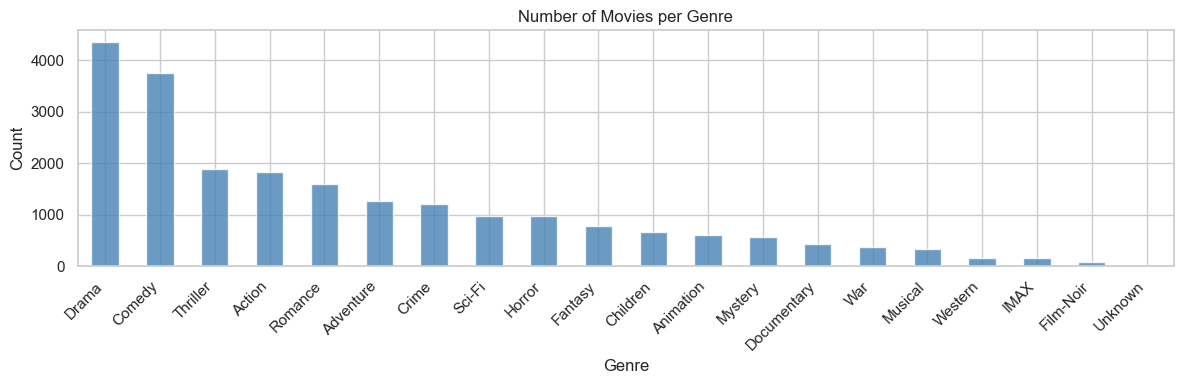

Saved: genre_distribution.png


In [8]:
# Genre frequency plot
genre_counts = genre_dummies.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
genre_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Number of Movies per Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/genre_distribution.png', dpi=150)
plt.show()
print('Saved: genre_distribution.png')

## 4. Feature Engineering – Ratings
### 4a. Convert timestamp → datetime features

In [9]:
ratings['datetime']     = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['rating_year']  = ratings['datetime'].dt.year
ratings['rating_month'] = ratings['datetime'].dt.month

# Drop raw timestamp (no longer needed)
ratings.drop(columns=['timestamp'], inplace=True)
ratings.head(3)

,userId,movieId,rating,datetime,rating_year,rating_month
0,1,1,4.0,2000-07-30 18:45:03,2000,7
1,1,3,4.0,2000-07-30 18:20:47,2000,7
2,1,6,4.0,2000-07-30 18:37:04,2000,7


### 4b. Normalise ratings

In [10]:
# Min-Max normalisation → [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
ratings['rating_norm'] = scaler.fit_transform(ratings[['rating']])

# Z-score standardisation
mu  = ratings['rating'].mean()
std = ratings['rating'].std()
ratings['rating_zscore'] = (ratings['rating'] - mu) / std

print(f"Raw rating   – mean: {mu:.4f}, std: {std:.4f}")
print(f"Normalised   – min: {ratings['rating_norm'].min():.2f}, max: {ratings['rating_norm'].max():.2f}")
print(f"Z-score      – mean: {ratings['rating_zscore'].mean():.4f}, std: {ratings['rating_zscore'].std():.4f}")
ratings[['rating', 'rating_norm', 'rating_zscore']].describe().round(4)

Raw rating   – mean: 3.5035, std: 1.0436
Normalised   – min: 0.00, max: 1.00
Z-score      – mean: 0.0000, std: 1.0000


,rating,rating_norm,rating_zscore
count,97801.0000,97801.0000,97801.0000
mean,3.5035,0.6674,0.0000
std,1.0436,0.2319,1.0000
min,0.5000,0.0000,-2.8781
25%,3.0000,0.5556,-0.4825
50%,3.5000,0.6667,-0.0034
75%,4.0000,0.7778,0.4758
max,5.0000,1.0000,1.4340


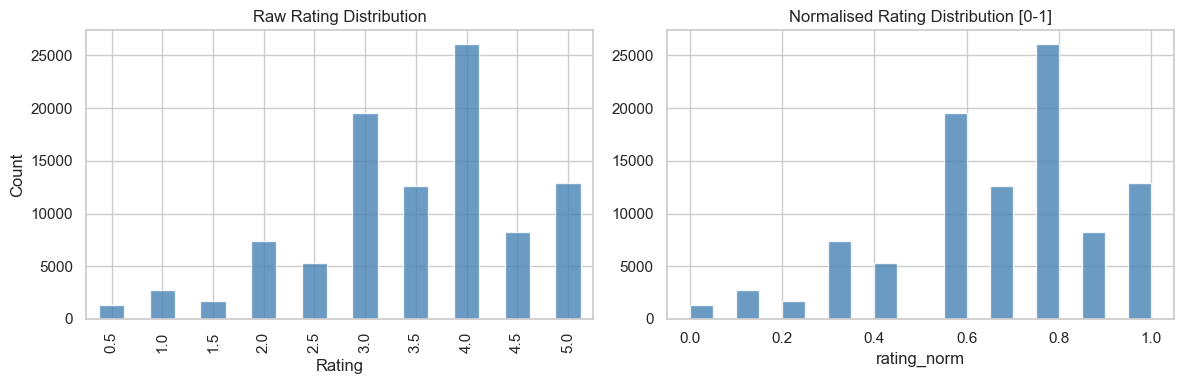

Saved: rating_distribution.png


In [11]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Raw Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings['rating_norm'].hist(bins=20, ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Normalised Rating Distribution [0-1]')
axes[1].set_xlabel('rating_norm')

plt.tight_layout()
plt.savefig('../figures/rating_distribution.png', dpi=150)
plt.show()
print('Saved: rating_distribution.png')

## 5. Merge Datasets

In [12]:
# Drop 'datetime' before merging (keep year/month features)
ratings_clean = ratings.drop(columns=['datetime'])

# Left join: keep all ratings, attach movie metadata
merged = ratings_clean.merge(movies_encoded, on='movieId', how='left')

print(f"Merged shape: {merged.shape}")
print(f"Missing after merge: {merged.isnull().sum()[merged.isnull().sum() > 0].to_dict()}")
merged.head(3)

Merged shape: (97801, 30)
Missing after merge: {}


,userId,movieId,rating,rating_year,rating_month,rating_norm,rating_zscore,title,genres,year,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,Unknown,War,Western
0,1,1,4.0,2000,7,0.777778,0.475767,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,2000,7,0.777778,0.475767,Grumpier Old Men (1995),Comedy|Romance,1995,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,1,6,4.0,2000,7,0.777778,0.475767,Heat (1995),Action|Crime|Thriller,1995,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


## 6. Dataset Statistics

In [13]:
n_users  = merged['userId'].nunique()
n_movies = merged['movieId'].nunique()
n_ratings = len(merged)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"Users   : {n_users}")
print(f"Movies  : {n_movies}")
print(f"Ratings : {n_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Users   : 600
Movies  : 9680
Ratings : 97801
Sparsity: 98.3161%


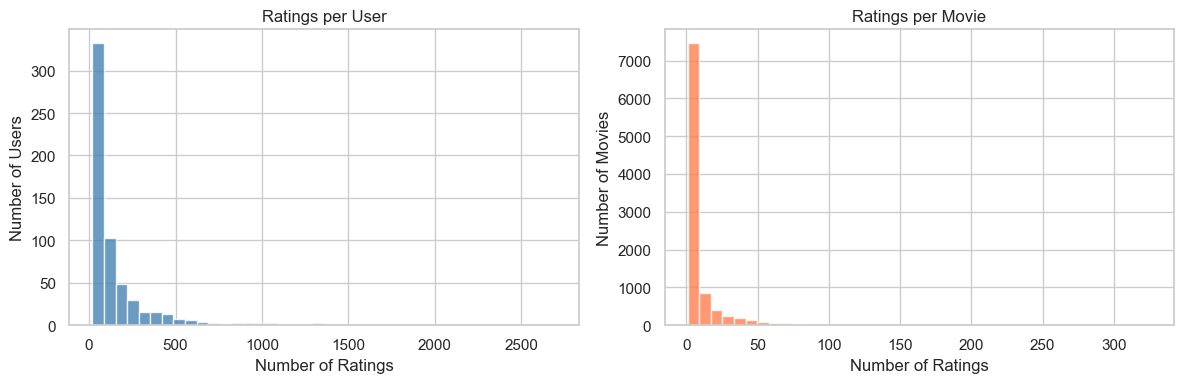

Saved: activity_distribution.png


In [14]:
# Ratings per user
ratings_per_user = merged.groupby('userId')['rating'].count()

# Ratings per movie
ratings_per_movie = merged.groupby('movieId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratings_per_user, bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

axes[1].hist(ratings_per_movie, bins=40, color='coral', alpha=0.8)
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Movies')

plt.tight_layout()
plt.savefig('../figures/activity_distribution.png', dpi=150)
plt.show()
print('Saved: activity_distribution.png')

In [15]:
print('Ratings per user stats:')
print(ratings_per_user.describe().round(2))
print()
print('Ratings per movie stats:')
print(ratings_per_movie.describe().round(2))

Ratings per user stats:
count     600.00
mean      163.00
std       268.38
min        19.00
25%        35.00
50%        69.50
75%       167.00
max      2698.00
Name: rating, dtype: float64

Ratings per movie stats:
count    9680.00
mean       10.10
std        21.75
min         1.00
25%         1.00
50%         3.00
75%         8.00
max       326.00
Name: rating, dtype: float64


## 7. Save Processed Files

In [16]:
# Full merged dataset (with genre dummies, normalised ratings, datetime features)
merged.to_csv('../data/processed/merged_data.csv', index=False)
print(f'Saved: merged_data.csv  ({merged.shape[0]} rows x {merged.shape[1]} cols)')

# Processed movies (with year + genre dummies)
movies_encoded.to_csv('../data/processed/movies_processed.csv', index=False)
print(f'Saved: movies_processed.csv  ({movies_encoded.shape[0]} rows x {movies_encoded.shape[1]} cols)')

# Processed ratings only (with normalised columns, no movie metadata)
ratings_clean.to_csv('../data/processed/ratings_processed.csv', index=False)
print(f'Saved: ratings_processed.csv  ({ratings_clean.shape[0]} rows x {ratings_clean.shape[1]} cols)')

Saved: merged_data.csv  (97801 rows x 30 cols)
Saved: movies_processed.csv  (9742 rows x 24 cols)


Saved: ratings_processed.csv  (97801 rows x 7 cols)


In [17]:
print('=== Preprocessing complete ===')
print(f'  merged_data.csv      – full merged dataset')
print(f'  movies_processed.csv – movies with year + genre dummies')
print(f'  ratings_processed.csv – ratings with normalised columns')

=== Preprocessing complete ===
  merged_data.csv      – full merged dataset
  movies_processed.csv – movies with year + genre dummies
  ratings_processed.csv – ratings with normalised columns
